In [105]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [106]:
%store -r cn0dbhz_merge_df
%store -r satcount_merge_df
%store -r elevationdeg_merge_df
%store -r energy_merge_df

%store -r satcountdelta_merge_df
%store -r energydelta_merge_df
%store -r cn0dbhzdelta_merge_df
%store -r cn0dbhzmean_merge_df
%store -r energystd_merge_df

In [107]:
print('Cn0DbHz Shape: ')
print(cn0dbhz_merge_df.shape)
print()
print('SatCount Shape: ')
print(satcount_merge_df.shape)
print()
print('SvElevationDegrees Shape: ')
print(elevationdeg_merge_df.shape)
print()
print('Energy Shape: ')
print(energy_merge_df.shape)
print()

Cn0DbHz Shape: 
(153631, 7)

SatCount Shape: 
(153631, 7)

SvElevationDegrees Shape: 
(153631, 7)

Energy Shape: 
(153631, 7)



In [108]:
merge_df = cn0dbhz_merge_df.merge(satcount_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCount']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(elevationdeg_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SvElevationDegrees']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(energy_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'TotalMotionEnergy']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

merge_df = merge_df.merge(satcountdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCountDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(energydelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzmean_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzMean']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(energystd_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyStd']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

In [109]:
print(merge_df)

                   drive_id        device  UnixTimeMillis    Cn0DbHz  \
0       2020-06-10-US-MTV-2  GooglePixel4   1591819502443  30.987097   
1       2020-06-10-US-MTV-2  GooglePixel4   1591819503443  31.315625   
2       2020-06-10-US-MTV-2  GooglePixel4   1591819509443  32.503226   
3       2020-06-10-US-MTV-2  GooglePixel4   1591819514443  31.681250   
4       2020-06-10-US-MTV-2  GooglePixel4   1591819515443  31.216667   
...                     ...           ...             ...        ...   
153626  2021-12-28-US-MTV-1     XiaomiMi8   1640724239000  25.916074   
153627  2021-12-28-US-MTV-1     XiaomiMi8   1640724240000  25.838720   
153628  2021-12-28-US-MTV-1     XiaomiMi8   1640724242000  25.539480   
153629  2021-12-28-US-MTV-1     XiaomiMi8   1640724243000  25.792816   
153630  2021-12-28-US-MTV-1     XiaomiMi8   1640724244000  25.816935   

        ErrorXEcefMeters  ErrorYEcefMeters  ErrorZEcefMeters  SatCount  \
0               0.528437          2.542246          2.295396 

In [110]:
print(merge_df.isna().sum())

drive_id                  0
device                    0
UnixTimeMillis            0
Cn0DbHz                   0
ErrorXEcefMeters          0
ErrorYEcefMeters          0
ErrorZEcefMeters          0
SatCount                  0
SvElevationDegrees        1
TotalMotionEnergy     20092
SatCountDelta             0
Cn0DbHzDelta              0
EnergyDelta               0
Cn0DbHzMean               0
EnergyStd                 0
dtype: int64


In [111]:
# drop null values

merge_df = merge_df.dropna(subset=['SvElevationDegrees', 'TotalMotionEnergy'])

print(merge_df.isna().sum())
print()
print('Merge Shape: ')
print(merge_df.shape)
print()

drive_id              0
device                0
UnixTimeMillis        0
Cn0DbHz               0
ErrorXEcefMeters      0
ErrorYEcefMeters      0
ErrorZEcefMeters      0
SatCount              0
SvElevationDegrees    0
TotalMotionEnergy     0
SatCountDelta         0
Cn0DbHzDelta          0
EnergyDelta           0
Cn0DbHzMean           0
EnergyStd             0
dtype: int64

Merge Shape: 
(133538, 15)



In [112]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'TotalMotionEnergy', 'SatCountDelta', 'EnergyDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean', 'EnergyStd']]
y = pd.Series(merge_df['ErrorXEcefMeters'])

In [113]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
# train multiple linear regression model

modelx = LinearRegression()

modelx.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [115]:
print("Coefficients:", modelx.coef_)  
print("Intercept:", modelx.intercept_)

Coefficients: [-0.14518447  0.03237154  0.05195194 -0.00141561 -0.00713255  0.00053021
  0.06587404 -0.26966417  0.0023666 ]
Intercept: 1.5146222818174864


In [116]:
y_train_pred = modelx.predict(X_train)

In [117]:
y_test_pred = modelx.predict(X_test)

In [118]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", modelx.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.04541678080070899
Mean Squared Error (MSE) 	: 6.900202255217752
Root Mean Squared Error (RMSE) 	: 2.6268236056533665


In [119]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", modelx.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.03931371280689655
Mean Squared Error (MSE) 	: 6.94493103193486
Root Mean Squared Error (RMSE) 	: 2.6353237053415013


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_58853/2859133257.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


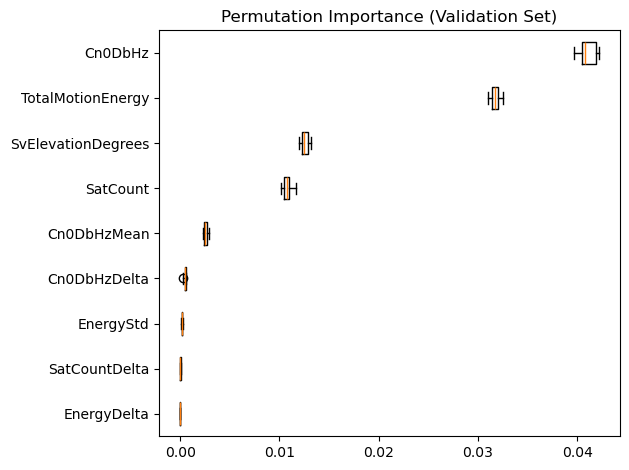

In [120]:
result = permutation_importance(
    modelx, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

In [121]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'TotalMotionEnergy', 'SatCountDelta', 'EnergyDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean', 'EnergyStd']]
y = pd.Series(merge_df['ErrorYEcefMeters'])

In [122]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
# train multiple linear regression model

modely = LinearRegression()

modely.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
print("Coefficients:", modely.coef_)  
print("Intercept:", modely.intercept_)

Coefficients: [-0.14650693 -0.0470196  -0.10265955 -0.00096911  0.00461076  0.00029938
  0.08134078 -0.18308436  0.00415654]
Intercept: 9.459282065312012


In [125]:
y_train_pred = modely.predict(X_train)

In [126]:
y_test_pred = modely.predict(X_test)

In [127]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", modely.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.02081822763788288
Mean Squared Error (MSE) 	: 10.907181410213461
Root Mean Squared Error (RMSE) 	: 3.302602217981067


In [128]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", modely.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.0216414258155182
Mean Squared Error (MSE) 	: 10.8609637324865
Root Mean Squared Error (RMSE) 	: 3.2955976290327826


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_58853/4278546562.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


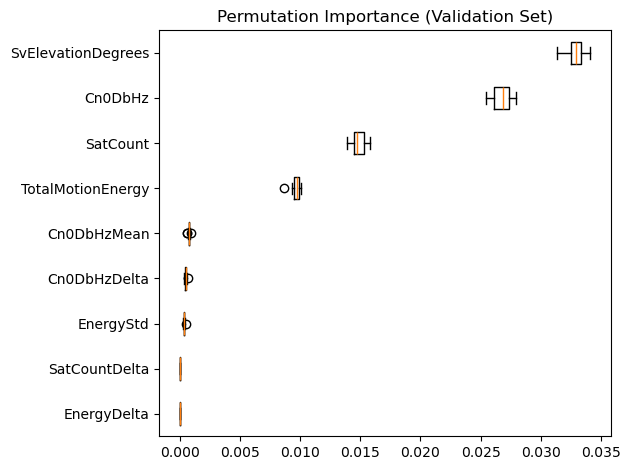

In [129]:
result = permutation_importance(
    modely, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

In [130]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'TotalMotionEnergy', 'SatCountDelta', 'EnergyDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean', 'EnergyStd']]
y = pd.Series(merge_df['ErrorZEcefMeters'])

In [131]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [132]:
# train multiple linear regression model

modelz = LinearRegression()

modelz.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [133]:
print("Coefficients:", modelz.coef_)  
print("Intercept:", modelz.intercept_)

Coefficients: [ 3.51387411e-02 -3.53604765e-02  4.04864576e-02  4.05674170e-04
  2.00685939e-02 -1.35196172e-04 -4.01736881e-02  1.71001946e-01
 -1.75614359e-03]
Intercept: -1.1608731377113821


In [134]:
y_train_pred = modelz.predict(X_train)

In [135]:
y_test_pred = modelz.predict(X_test)

In [136]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", modelz.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.011792480494925428
Mean Squared Error (MSE) 	: 10.517843035355465
Root Mean Squared Error (RMSE) 	: 3.243122420655049


In [137]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", modelz.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.012965403518732765
Mean Squared Error (MSE) 	: 10.642963896093976
Root Mean Squared Error (RMSE) 	: 3.2623555747487085


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_58853/1873477217.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


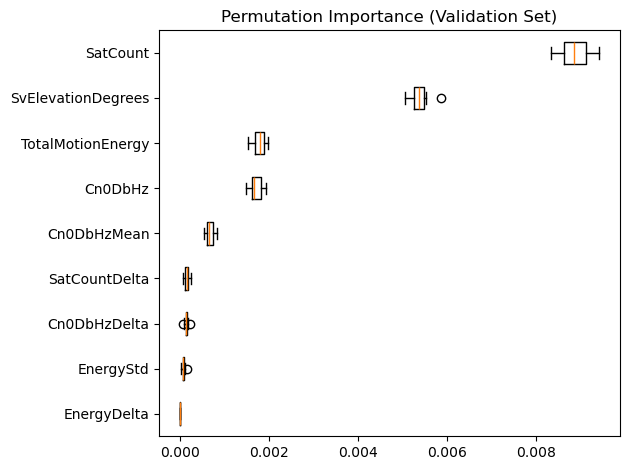

In [138]:
result = permutation_importance(
    modelz, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

In [139]:
%store -r merge_test_df

In [140]:
features_test_df = merge_test_df.drop(columns=['UnixTimeMillis', 'tripId', 'WlsPositionXEcefMeters','WlsPositionYEcefMeters', 'WlsPositionZEcefMeters'])

predicted_errorx = modelx.predict(features_test_df)
predicted_errory = modely.predict(features_test_df)
predicted_errorz = modelz.predict(features_test_df)

print('predicted_errorx: ')
print(predicted_errorx)
print()
print('predicted_errory: ')
print(predicted_errory)
print()
print('predicted_errorz: ')
print(predicted_errorz)
print()

predicted_errorx: 
[ 0.65641253  0.6404163   0.61370943 ... -1.13567841 -0.97209249
 -0.98823519]

predicted_errory: 
[-0.38158816 -0.39450686 -0.31309042 ... -0.24258628 -0.39957179
 -0.16751506]

predicted_errorz: 
[-0.00551219 -0.00636751 -0.02745861 ...  0.93255441  0.92622758
  0.80321926]



In [141]:
submission_ecef = pd.DataFrame()
submission_ecef['MeasurementX_Corr'] = merge_test_df['WlsPositionXEcefMeters'] + predicted_errorx
submission_ecef['MeasurementY_Corr'] = merge_test_df['WlsPositionYEcefMeters'] + predicted_errory
submission_ecef['MeasurementZ_Corr'] = merge_test_df['WlsPositionZEcefMeters'] + predicted_errorz

In [142]:
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

lon, lat, alt = transformer.transform(
    submission_ecef['MeasurementX_Corr'].values, 
    submission_ecef['MeasurementY_Corr'].values,
    submission_ecef['MeasurementZ_Corr'].values,
)

In [143]:
submission = pd.DataFrame()
submission['tripId'] = merge_test_df['tripId']
submission['UnixTimeMillis'] = merge_test_df['UnixTimeMillis']
submission['LatitudeDegrees'] = lat
submission['LongitudeDegrees'] = lon

print(submission)
print()
submission.to_csv('./SUBMISSIONS/LINEAR_REGRESSION/submission.csv', index=False)

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395828       -122.102959  
1            37.395851       -122.102978  
2            37.395835       -122.102993  
3          

In [144]:
print(merge_test_df.isna().sum())

UnixTimeMillis            0
Cn0DbHz                   0
SatCount                  0
SvElevationDegrees        0
tripId                    0
TotalMotionEnergy         0
SatCountDelta             0
EnergyDelta               0
Cn0DbHzDelta              0
Cn0DbHzMean               0
EnergyStd                 0
WlsPositionXEcefMeters    0
WlsPositionYEcefMeters    0
WlsPositionZEcefMeters    0
dtype: int64


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_58853/2859133257.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


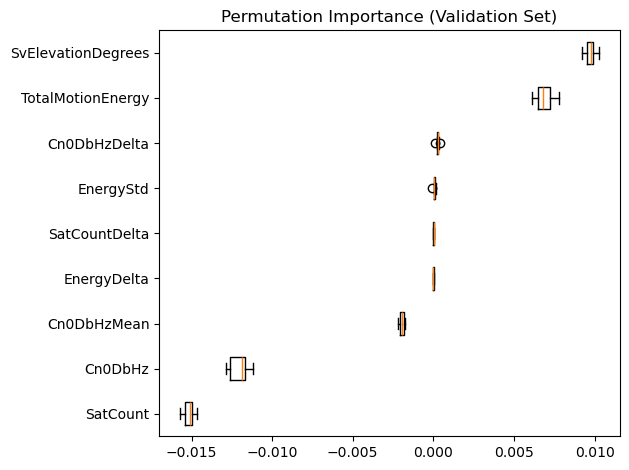

In [145]:
result = permutation_importance(
    modelx, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()